In [42]:
# Importing libraries

# Manipulation
import pandas as pd

# Visualisation
import seaborn as sns  

# Classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import export_text
from sklearn import tree
from sklearn.metrics import classification_report, accuracy_score 
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

# Visualisation
import matplotlib.pyplot as plt

# Numerical Computing
import numpy as np

# Manipulating Random Values
import random

print("Libraries imported successfully!!")

Libraries imported successfully!!


In [43]:
# Uses pandas to declare dataset as a variable
df = pd.read_csv(r'C:\Users\LENOVO L14\Downloads\Jupyter Notebook\plant_health_data.csv')
print("Dataset has been located and read!!")

Dataset has been located and read!!


In [44]:
# Used built-in functions
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1200, 14)


In [4]:
df.head()

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   object 
 1   Plant_ID                1200 non-null   int64  
 2   Soil_Moisture           1200 non-null   float64
 3   Ambient_Temperature     1200 non-null   float64
 4   Soil_Temperature        1200 non-null   float64
 5   Humidity                1200 non-null   float64
 6   Light_Intensity         1200 non-null   float64
 7   Soil_pH                 1200 non-null   float64
 8   Nitrogen_Level          1200 non-null   float64
 9   Phosphorus_Level        1200 non-null   float64
 10  Potassium_Level         1200 non-null   float64
 11  Chlorophyll_Content     1200 non-null   float64
 12  Electrochemical_Signal  1200 non-null   float64
 13  Plant_Health_Status     1200 non-null   object 
dtypes: float64(11), int64(1), object(2)
memo

In [6]:
df.isnull().sum()

Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64

In [7]:
df.describe()

,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,5.500000,25.106918,23.999130,19.957794,54.853165,612.637265,6.524102,30.106751,30.264484,30.112088,34.749591,0.987764
std,2.873479,8.677725,3.441561,2.932073,8.784916,228.318853,0.581755,11.514396,11.466846,11.668085,8.766995,0.575116
min,1.000000,10.000724,18.001993,15.003710,40.028758,200.615482,5.507392,10.003650,10.017690,10.000606,20.025511,0.002376
25%,3.000000,17.131893,21.101766,17.353027,47.019694,416.878983,6.026042,20.249774,20.894445,19.585561,27.463350,0.487982
50%,5.500000,25.168333,23.889044,19.911473,54.692069,617.240221,6.540524,30.138590,30.019385,30.495054,34.433427,0.981647
75%,8.000000,32.370231,27.042634,22.596851,62.451053,811.474690,7.030039,40.184737,40.131459,40.108296,42.232637,1.473142
max,10.000000,39.993164,29.990886,24.995929,69.968871,999.856262,7.497823,49.951136,49.980700,49.981945,49.990811,1.996116


In [11]:
# Count the number of plants under each health status
count_high = (df['Plant_Health_Status'] == 'High Stress').sum()
count_moderate = (df['Plant_Health_Status'] == 'Moderate Stress').sum()
count_healthy = (df['Plant_Health_Status'] == 'Healthy').sum()

print(f"Number of High Stress plants: {count_high}")
print(f"Number of Moderate Stress plants: {count_moderate}")
print(f"Number of Healthy plants: {count_healthy}")

Number of High Stress plants: 500
Number of Moderate Stress plants: 401
Number of Healthy plants: 299


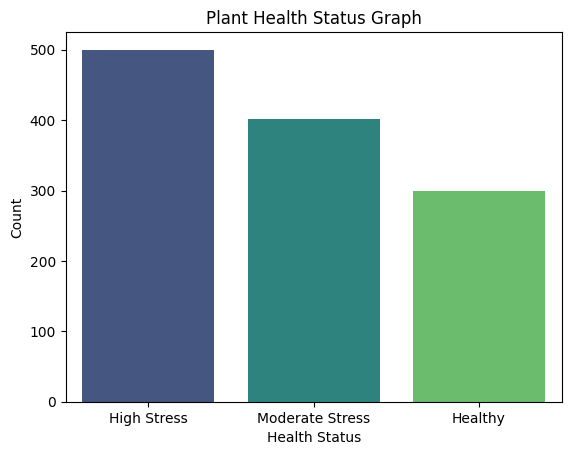

In [12]:
sns.countplot(data=df, x='Plant_Health_Status', hue='Plant_Health_Status', palette='viridis', legend=False)
plt.title('Plant Health Status Graph')
plt.xlabel('Health Status')
plt.ylabel('Count')
plt.show()

In [13]:
health_map = {'Healthy': 0, 'Moderate Stress': 1, 'High Stress': 2}
df['Health_Score'] = df['Plant_Health_Status'].map(health_map)

features = [
    'Soil_Moisture',
    'Ambient_Temperature',
    'Soil_Temperature',
    'Humidity',
    'Light_Intensity',
    'Soil_pH',
    'Nitrogen_Level',
    'Phosphorus_Level',
    'Potassium_Level',
    'Chlorophyll_Content',
    'Electrochemical_Signal'
]

X = df[features]
y = df['Health_Score']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Decision Tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)  # Increase depth for more detail
tree.fit(X_train, y_train)

# Evaluate
y_pred = tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=health_map.keys()))

Accuracy: 0.9958333333333333
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00        65
Moderate Stress       0.99      1.00      0.99        90
    High Stress       1.00      0.99      0.99        85

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



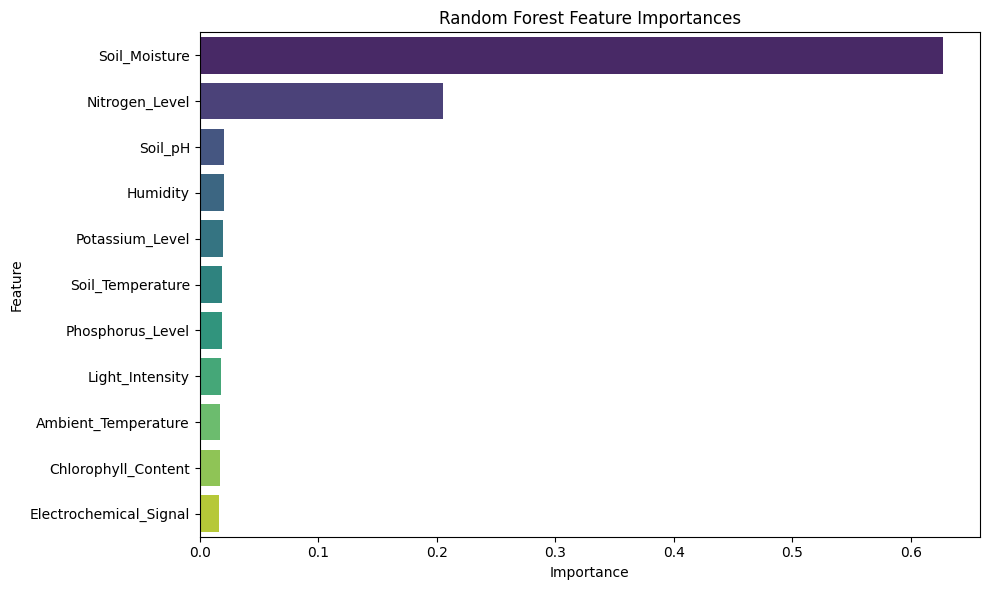

In [14]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

# Feature importances
importances = pd.Series(forest.feature_importances_, index=features).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [15]:
# Moisture < 20
below_20 = df[df['Soil_Moisture'] < 20]
most_common_below_20 = below_20['Plant_Health_Status'].value_counts().idxmax()
print(f"Most common Plant Health Status for Soil Moisture < 20: {most_common_below_20}")

# Moisture around 25
around_25 = df[(df['Soil_Moisture'] >= 24.5) & (df['Soil_Moisture'] <= 25.5)]
most_common_around_25 = around_25['Plant_Health_Status'].value_counts().idxmax()
print(f"Most common Plant Health Status around Soil Moisture 25: {most_common_around_25}")

# Moisture > 35
above_35 = df[df['Soil_Moisture'] > 35]
most_common_above_35 = above_35['Plant_Health_Status'].value_counts().idxmax()
print(f"Most common Plant Health Status for Soil Moisture > 35: {most_common_above_35}")

Most common Plant Health Status for Soil Moisture < 20: High Stress
Most common Plant Health Status around Soil Moisture 25: Moderate Stress
Most common Plant Health Status for Soil Moisture > 35: Healthy


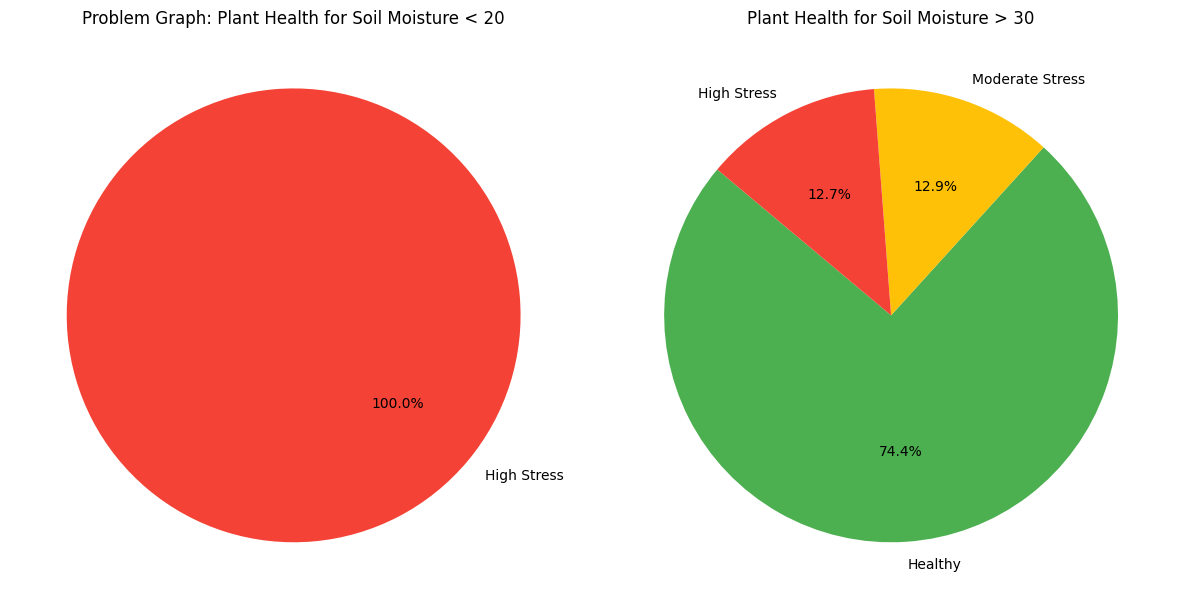

In [16]:
# Filter for low moisture levels (<20)
low_moisture_df = df[df['Soil_Moisture'] < 20]
low_counts = low_moisture_df['Plant_Health_Status'].value_counts()

# Filter for high moisture levels (>30)
high_moisture_df = df[df['Soil_Moisture'] > 30]
high_counts = high_moisture_df['Plant_Health_Status'].value_counts()

# Define consistent colors for clarity
colors = {
    'Healthy': '#4CAF50',
    'Moderate Stress': '#FFC107',
    'High Stress': '#F44336'
}

# Plot the pie charts
plt.figure(figsize=(12, 6))

# Pie chart for moisture < 20
plt.subplot(1, 2, 1)
plt.pie(
    low_counts,
    labels=low_counts.index,
    autopct='%1.1f%%',
    colors=[colors.get(x, '#999999') for x in low_counts.index],
    startangle=140
)
plt.title('Problem Graph: Plant Health for Soil Moisture < 20')

# Pie chart for moisture > 30
plt.subplot(1, 2, 2)
plt.pie(
    high_counts,
    labels=high_counts.index,
    autopct='%1.1f%%',
    colors=[colors.get(x, '#999999') for x in high_counts.index],
    startangle=140
)
plt.title('Plant Health for Soil Moisture > 30')

plt.tight_layout()
plt.show()

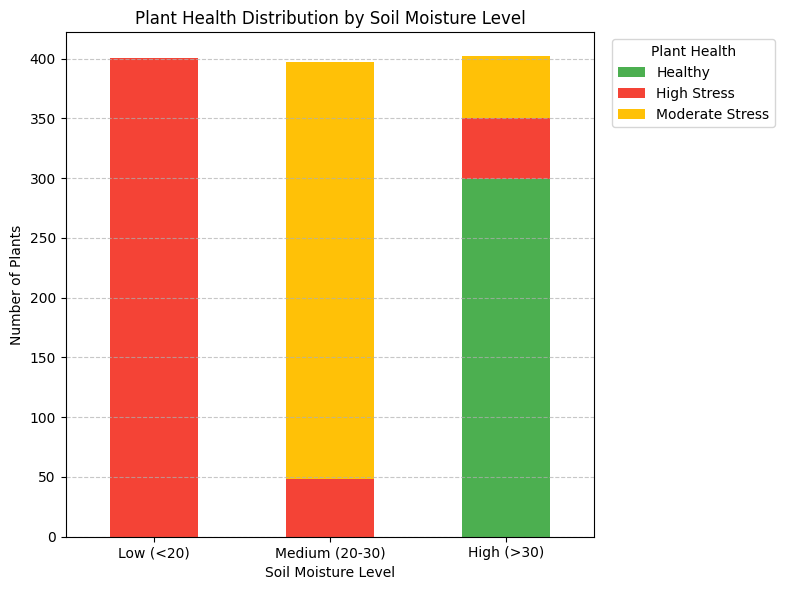

In [17]:
# Moisture Filter function
def moisture_category(moisture):
    if moisture < 20:
        return 'Low (<20)'
    elif 20 <= moisture <= 30:
        return 'Medium (20-30)'
    else:
        return 'High (>30)'

df_copy = df.copy()
df_copy['Moisture Level'] = df_copy['Soil_Moisture'].apply(moisture_category)

# Group and count
grouped = df_copy.groupby(['Moisture Level', 'Plant_Health_Status']).size().unstack().fillna(0)

order = ['Low (<20)', 'Medium (20-30)', 'High (>30)']
grouped = grouped.reindex(order)

colors = {
    'Healthy': '#4CAF50',
    'Moderate Stress': '#FFC107',
    'High Stress': '#F44336'
}

plt.figure(figsize=(10, 6))
ax = grouped.plot(kind='bar', stacked=True, color=[colors.get(col, '#999999') for col in grouped.columns], ax=plt.gca())

# Legend Display
plt.legend(title='Plant Health', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('Plant Health Distribution by Soil Moisture Level')
plt.xlabel('Soil Moisture Level')
plt.ylabel('Number of Plants')
plt.xticks(rotation=0)
plt.tight_layout(rect=[0, 0, 0.8, 1])  # Allow extra space on right for legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
# Filter
filtered_records = df[
    (df['Soil_Moisture'].between(23, 26)) & 
    (df['Humidity'].between(50, 55))
]

# Count
count_records = filtered_records.shape[0]

most_common_status = filtered_records['Plant_Health_Status'].mode()[0]

print(f"Number of records: {count_records}")
print(f"Most common Plant Health Status: {most_common_status}")

Number of records: 19
Most common Plant Health Status: Moderate Stress


In [25]:
moderate_stress_count = (filtered_records['Plant_Health_Status'] == 'Moderate Stress').sum()
percentage = (moderate_stress_count / count_records) * 100

print(f"Number of 'Moderate Stress' status plants: {moderate_stress_count} out of {count_records}")
print(f"Percentage of 'Moderate Stress' plants: {percentage:.2f}%")

Number of 'Moderate Stress' status plants: 19 out of 19
Percentage of 'Moderate Stress' plants: 100.00%


In [26]:
filtered_records = df[
    (df['Soil_Moisture'].between(30, 35)) & 
    (df['Humidity'].between(55, 65))
]

count_records = filtered_records.shape[0]

most_common_status = filtered_records['Plant_Health_Status'].mode()[0]

print(f"Number of records: {count_records}")
print(f"Most common Plant Health Status: {most_common_status}")

Number of records: 70
Most common Plant Health Status: Healthy


In [28]:
healthy_stress_count = (filtered_records['Plant_Health_Status'] == 'Healthy').sum()
percentage = (healthy_stress_count / count_records) * 100

print(f"Number of 'Healthy' status plants: {healthy_stress_count} out of {count_records}")
# This is a 71% higher health rate than the previous range
print(f"Percentage of 'Healthy' plants: {percentage:.2f}%")

Number of 'Healthy' status plants: 50 out of 70
Percentage of 'Healthy' plants: 71.43%


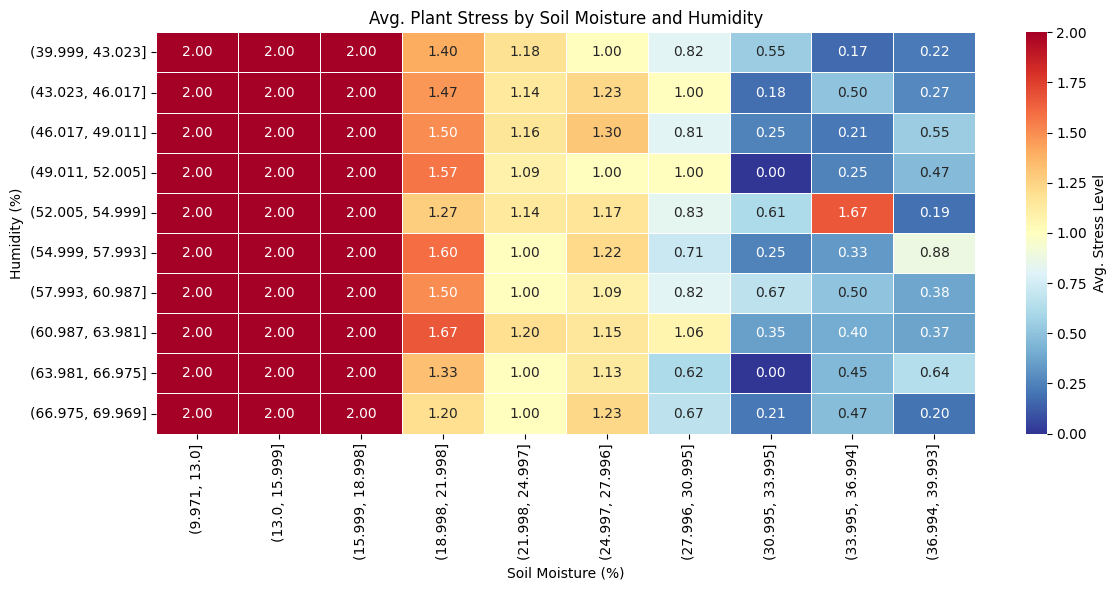

In [30]:
health_map = {'Healthy': 0, 'Moderate Stress': 1, 'High Stress': 2}
df['Health_Score'] = df['Plant_Health_Status'].map(health_map)

df['Moisture_Bin'] = pd.cut(df['Soil_Moisture'], bins=10)
df['Humidity_Bin'] = pd.cut(df['Humidity'], bins=10)

pivot = df.pivot_table(index='Humidity_Bin', columns='Moisture_Bin', values='Health_Score', aggfunc='mean', observed = False)

# Notice the difference between 27 and 30 SM as well as consistency in higher humidity
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='RdYlBu_r', annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Avg. Stress Level'})
plt.title('Avg. Plant Stress by Soil Moisture and Humidity')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

In [31]:
df['Nitrogen_Level'].describe()

count    1200.000000
mean       30.106751
std        11.514396
min        10.003650
25%        20.249774
50%        30.138590
75%        40.184737
max        49.951136
Name: Nitrogen_Level, dtype: float64

In [32]:
# Nitrogen < 20 (Low Nitrogen)
low_nitrogen = df[df['Nitrogen_Level'] < 20]
most_common_low = low_nitrogen['Plant_Health_Status'].value_counts().idxmax()
print(f"Most common Plant Health Status for Nitrogen < 20: {most_common_low}")

# Nitrogen around 30 (Optimal Range)
optimal_nitrogen = df[(df['Nitrogen_Level'] >= 29) & (df['Nitrogen_Level'] <= 31)]
most_common_optimal = optimal_nitrogen['Plant_Health_Status'].value_counts().idxmax()
print(f"Most common Plant Health Status around Nitrogen 30: {most_common_optimal}")

# Nitrogen > 40 (High Nitrogen)
high_nitrogen = df[df['Nitrogen_Level'] > 40]
most_common_high = high_nitrogen['Plant_Health_Status'].value_counts().idxmax()
print(f"Most common Plant Health Status for Nitrogen > 40: {most_common_high}")

Most common Plant Health Status for Nitrogen < 20: High Stress
Most common Plant Health Status around Nitrogen 30: Moderate Stress
Most common Plant Health Status for Nitrogen > 40: Healthy


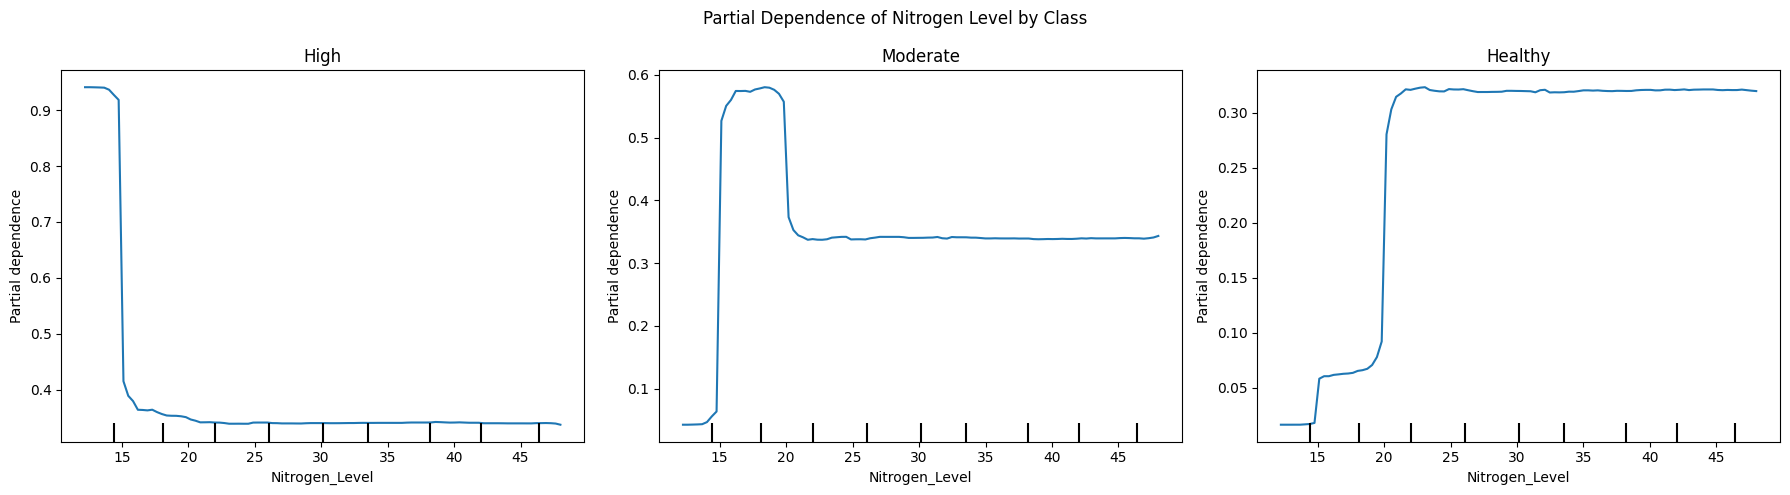

In [35]:
class_labels = ['High', 'Moderate', 'Healthy']
class_targets = [2, 1, 0]  

fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, cls in enumerate(class_targets):
    PartialDependenceDisplay.from_estimator(
        forest, X, 
        features=['Nitrogen_Level'], 
        target=cls,
        ax=ax[i],
        response_method='predict_proba'
    )
    ax[i].set_title(f'{class_labels[i]}')

plt.suptitle('Partial Dependence of Nitrogen Level by Class')
plt.tight_layout()
plt.show()


In [36]:
# Finding averages
avg_air_temp = df['Ambient_Temperature'].mean()
avg_soil_temp = df['Soil_Temperature'].mean()

# Temperature difference (air - soil)
temperature_diff = df['Ambient_Temperature'] - df['Soil_Temperature']
avg_temp_diff = temperature_diff.mean()

# Display Results
print(f"Average Air Temperature: {avg_air_temp:.2f}°C")
print(f"Average Soil Temperature: {avg_soil_temp:.2f}°C")
print(f"Average Temperature Difference (Air - Soil): {avg_temp_diff:.2f}°C")

Average Air Temperature: 24.00°C
Average Soil Temperature: 19.96°C
Average Temperature Difference (Air - Soil): 4.04°C


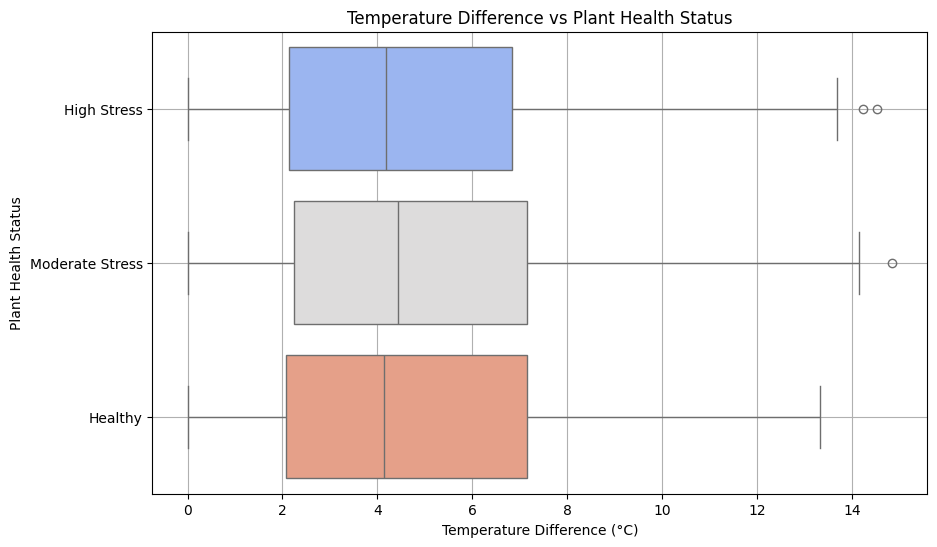

In [37]:
df['Temp_Diff'] = np.abs(df['Ambient_Temperature'] - df['Soil_Temperature'])

health_order = ['High Stress', 'Moderate Stress', 'Healthy']

# Plot boxplot - Helps find range, deviation, mean and outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Temp_Diff', y='Plant_Health_Status', hue='Plant_Health_Status', order=health_order, palette='coolwarm',legend=False)
plt.title('Temperature Difference vs Plant Health Status')
plt.xlabel('Temperature Difference (°C)')
plt.ylabel('Plant Health Status')
plt.grid(True)
plt.show()

In [38]:
highest_ph = df['Soil_pH'].max()
lowest_ph = df['Soil_pH'].min()

mean_ph = df['Soil_pH'].mean()

print(f"Range of Soil_pH levels: {lowest_ph:.2f} - {highest_ph:.2f}")
print(f"Soil pH Average: {mean_ph:.2f}")

Range of Soil_pH levels: 5.51 - 7.50
Soil pH Average: 6.52


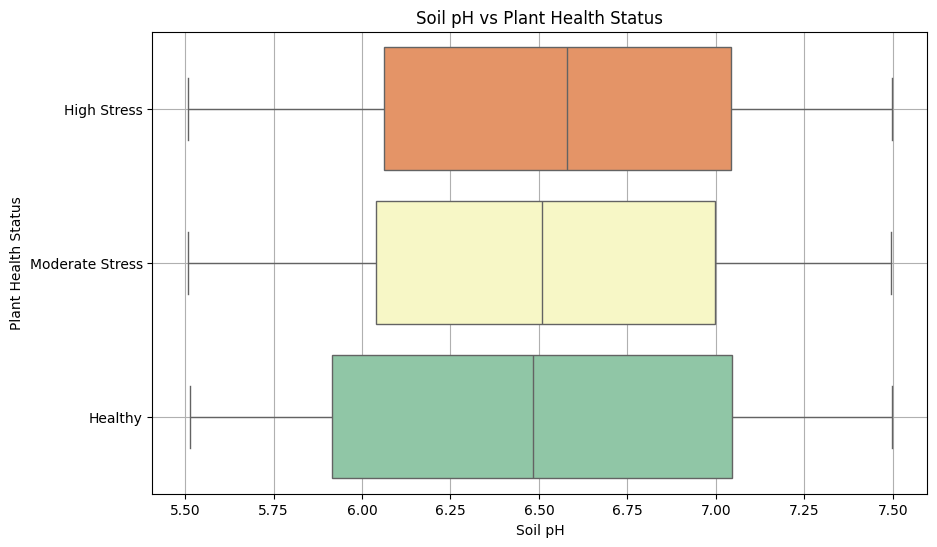

In [39]:
health_order = ['High Stress', 'Moderate Stress', 'Healthy']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Soil_pH', y='Plant_Health_Status', order=health_order, hue='Plant_Health_Status', palette='Spectral')
plt.title('Soil pH vs Plant Health Status')
plt.xlabel('Soil pH')
plt.ylabel('Plant Health Status')
plt.grid(True)
plt.show()